# Bitcoin Proof of Work Analysis

This notebook investigates the time, energy, and security aspects of Bitcoin mining using the Proof of Work (PoW) strategy.

In [4]:
# imports
import requests
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from datetime import datetime

In [1]:
# constants
BLOCK_TIME_MINUTES = 10  # Average time to mine a block
BLOCK_REWARD_BTC = 6.25  # Current reward per block (subject to halving)
HASHRATE_API_URL = 'https://api.blockchain.info/charts/hash-rate?timespan=all&format=json'
ENERGY_CONSUMPTION_TWH = 175.87  # Annual energy consumption in TWh

## Plot Bitcoin Hashrate over time

In [2]:
# Fetch Bitcoin hashrate data
def fetch_hashrate_data(api_url=HASHRATE_API_URL):
    """
    Get Bitcoin hashrate data from API for all available data.
    Parameters: api_url (str) - URL to fetch data from.
    Returns: DataFrame with Date and Hashrate.
    """
    response = requests.get(api_url)
    data = response.json()
    df = pd.DataFrame(data['values'])
    df['x'] = pd.to_datetime(df['x'], unit='s')
    df.rename(columns={'x': 'Date', 'y': 'Hashrate (EH/s)'}, inplace=True)
    df.sort_values('Date', inplace=True)
    return df

In [3]:
hashrate_df = fetch_hashrate_data()
hashrate_df.head()

NameError: name 'requests' is not defined

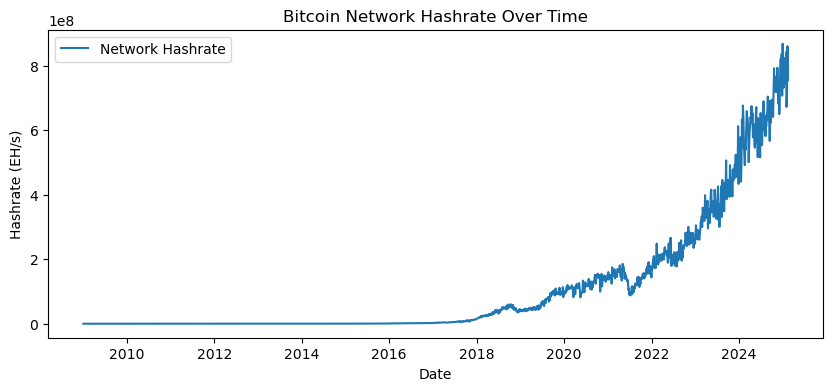

In [ ]:
def plot_hashrate(df):
    """
    Plot Bitcoin hashrate over time.
    Parameters: df (DataFrame) - Data with Date and Hashrate.
    Returns: None (Displays plot).
    """
    plt.figure(figsize=(10, 4))
    sns.lineplot(data=df, x='Date', y='Hashrate (EH/s)', label='Network Hashrate')
    plt.xlabel('Date')
    plt.ylabel('Hashrate (EH/s)')
    plt.title('Bitcoin Network Hashrate Over Time')
    plt.legend()
    plt.show()

plot_hashrate(hashrate_df)

Why does hashrate go up:

* increased popularity - more guesses per second 
* advances in hardware allowing for more hashes per second 
* increased mining difficulty - maintain the 10-min block time 

## Energy per Bitcoin Mined

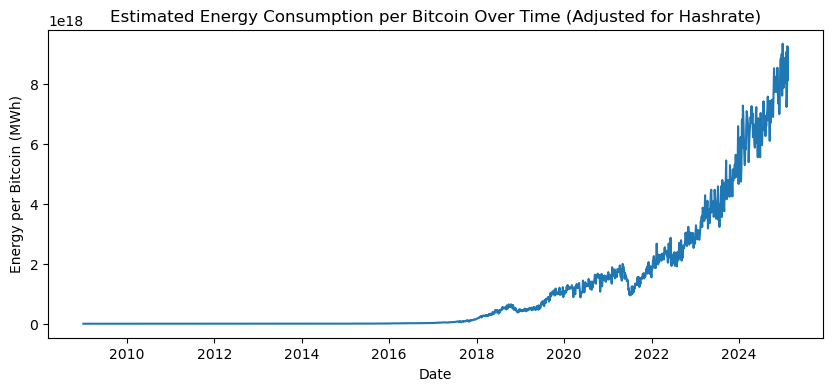

In [ ]:
# Plot dynamic energy per Bitcoin mined over time accounting for hashrate
def plot_energy_over_time(df, block_reward=BLOCK_REWARD_BTC):
    """
    Plot estimated energy consumption per Bitcoin mined over time, accounting for hashrate changes.
    Parameters: df (DataFrame) - Data with Date and Hashrate.
    Returns: None (Displays plot).
    """
    # Normalize energy consumption to hashrate changes
    initial_hashrate = df['Hashrate (EH/s)'].iloc[0]
    df['Relative Hashrate'] = df['Hashrate (EH/s)'] / initial_hashrate

    # Total energy scaled to hashrate growth
    df['Estimated Annual Energy (MWh)'] = (ENERGY_CONSUMPTION_TWH * 1e6) * df['Relative Hashrate']

    # Calculate estimated BTC mined per year
    annual_blocks = (60 / BLOCK_TIME_MINUTES) * 24 * 365  # Annual blocks mined
    df['Estimated BTC Mined'] = annual_blocks * block_reward

    # Calculate energy per BTC mined over time
    df['Energy per BTC (MWh)'] = df['Estimated Annual Energy (MWh)'] / df['Estimated BTC Mined']

    plt.figure(figsize=(10, 4))
    sns.lineplot(data=df, x='Date', y='Energy per BTC (MWh)')
    plt.xlabel('Date')
    plt.ylabel('Energy per Bitcoin (MWh)')
    plt.title('Estimated Energy Consumption per Bitcoin Over Time (Adjusted for Hashrate)')
    plt.show()

plot_energy_over_time(hashrate_df)

## Network Security Growth

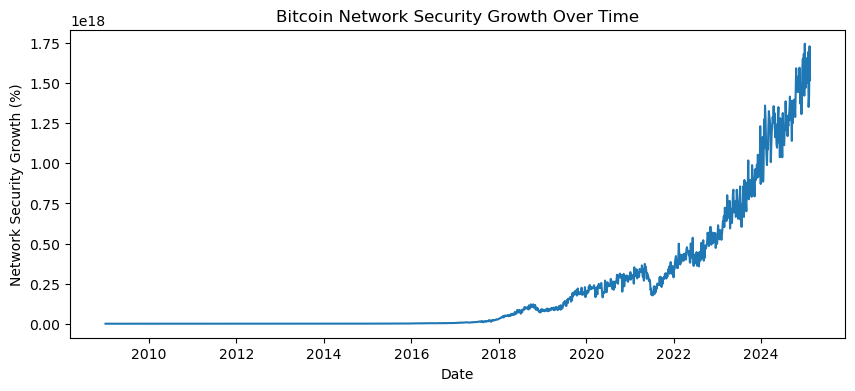

In [ ]:
def plot_network_security(df):
    """
    Plot Bitcoin network security growth over time based on hashrate.
    Parameters: df (DataFrame) - Data with Date and Hashrate.
    Returns: None (Displays plot).
    """
    initial_hashrate = df['Hashrate (EH/s)'].iloc[0]
    df['Security Growth (%)'] = ((df['Hashrate (EH/s)'] - initial_hashrate) / initial_hashrate) * 100

    plt.figure(figsize=(10, 4))
    sns.lineplot(data=df, x='Date', y='Security Growth (%)')
    plt.xlabel('Date')
    plt.ylabel('Network Security Growth (%)')
    plt.title('Bitcoin Network Security Growth Over Time')
    plt.show()

plot_network_security(hashrate_df)

Flat Growth (2009 - 2016): Early Mining Era: Mining was done on personal computers (CPUs) and later GPUs, resulting in low hashrate and security. Few miners contributed, keeping network security relatively weak.



Exponential Growth (2016 - 2024): 
* Introduction of ASICs around 2013-2014 led to rapid hashrate growth.
* Mining Farms: Large-scale mining operations significantly increased network power.
* Bitcoin Price Increases: Rising Bitcoin prices incentivized more miners to participate.

## Transaction Security based on confirmations and attacker hash

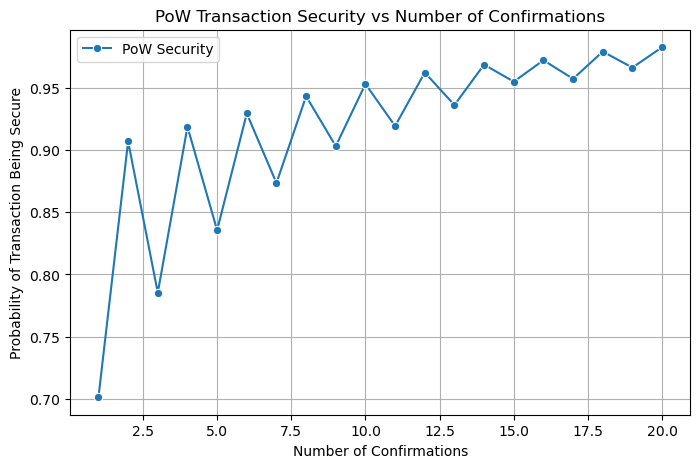

In [ ]:
# Simulate PoW transaction security based on confirmations and attacker hashrate
def simulate_pow_transaction_security(num_confirmations=10, attacker_hashrate=0.3, num_simulations=10000):
    """
    Simulate PoW transaction security by estimating attack success probability.
    Parameters: num_confirmations (int), attacker_hashrate (float), num_simulations (int).
    Returns: Attack success probability (float).
    """
    attack_success_count = 0

    for _ in range(num_simulations):
        attacker_blocks = np.sum(np.random.rand(num_confirmations) < attacker_hashrate)
        if attacker_blocks > num_confirmations / 2:
            attack_success_count += 1

    attack_probability = attack_success_count / num_simulations
    return attack_probability



# Plot PoW transaction security over varying confirmation levels
def plot_pow_transaction_security():
    """
    Plot PoW transaction security across different confirmation levels.
    Returns: None (Displays plot).
    """
    confirmations = np.arange(1, 21)
    security_probs = [1 - simulate_pow_transaction_security(num_confirmations=n) for n in confirmations]

    plt.figure(figsize=(8, 5))
    sns.lineplot(x=confirmations, y=security_probs, marker='o', linestyle='-', label='PoW Security')
    plt.xlabel('Number of Confirmations')
    plt.ylabel('Probability of Transaction Being Secure')
    plt.title('PoW Transaction Security vs Number of Confirmations')
    plt.legend()
    plt.grid(True)
    plt.show()


plot_pow_transaction_security()

### Filter Data since PoS Creation (Etherum Merge)

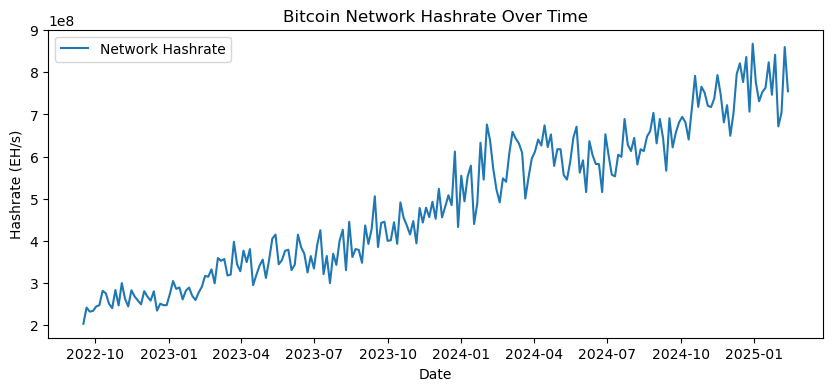

In [ ]:
# Filter data since Ethereum's transition to PoS (September 15, 2022)
pos_start_date = "2022-09-15"
pos_df = hashrate_df[hashrate_df["Date"] >= pos_start_date]

# Plot to visualize changes
plot_hashrate(pos_df)

### Compare PoW and PoS Energy Consumption

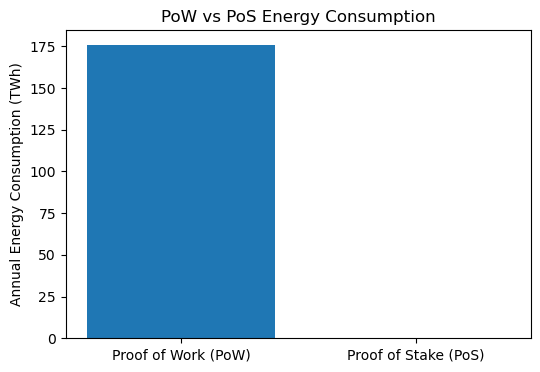

In [ ]:
# Approximate energy consumption per year (PoW vs PoS)
energy_pow_twh = 175.87  # Example: Bitcoin annual energy usage
energy_pos_twh = 0.002  # Example: Ethereum PoS estimate

labels = ["Proof of Work (PoW)", "Proof of Stake (PoS)"]
energy_values = [energy_pow_twh, energy_pos_twh]

plt.figure(figsize=(6, 4))
plt.bar(labels, energy_values)
plt.ylabel("Annual Energy Consumption (TWh)")
plt.title("PoW vs PoS Energy Consumption")
plt.show()

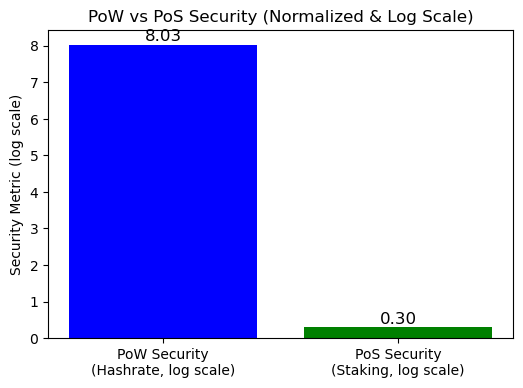

In [ ]:
# Normalize security measures
security_pow = hashrate_df["Hashrate (EH/s)"].mean()
security_pos = 0.99  # Assumed normalized value for staking security

# Normalize both on a log scale for fair comparison
pow_security_normalized = np.log10(security_pow)  # Log scale
pos_security_normalized = np.log10(security_pos + 1)  # Avoid log(0)

labels = ["PoW Security\n(Hashrate, log scale)", "PoS Security\n(Staking, log scale)"]
values = [pow_security_normalized, pos_security_normalized]

plt.figure(figsize=(6, 4))
plt.bar(labels, values, color=["blue", "green"])

plt.ylabel("Security Metric (log scale)")
plt.title("PoW vs PoS Security (Normalized & Log Scale)")

# Add data labels
for i, v in enumerate(values):
    plt.text(i, v + 0.1, f"{v:.2f}", ha='center', fontsize=12)

plt.show()

### Hypothetical modeling of network that has both methodologies at play

In [ ]:
# Define PoW-PoS ratios (0% PoW to 100% PoW)
ratios = np.arange(0, 1.1, 0.1)

# Mock security values
security_pow = np.log10(150 * 10**6)  
security_pos = np.log10(0.99 + 1)  

# Mock carbon footprint values
carbon_pow = np.log10(175.87 * 400)  
carbon_pos = np.log10(0.002 * 400 + 1)  

# Compute trade-offs
security_values = ratios * security_pow + (1 - ratios) * security_pos
carbon_values = ratios * carbon_pow + (1 - ratios) * carbon_pos

# Economic costs (PoW = expensive, PoS = cheap)
cost_pow = 50  # PoW cost per transaction ($)
cost_pos = 0.5  # PoS cost per transaction ($)
economic_costs = ratios * cost_pow + (1 - ratios) * cost_pos

# Scalability (PoW = low TPS, PoS = high TPS)
scalability_pow = 7  
scalability_pos = 10000  
scalability_values = ratios * scalability_pow + (1 - ratios) * scalability_pos

# Normalize values for log visualization
carbon_values_normalized = np.log10(carbon_values)
security_values_normalized = np.log10(security_values)
economic_costs_normalized = np.log10(economic_costs)
scalability_values_normalized = np.log10(scalability_values)

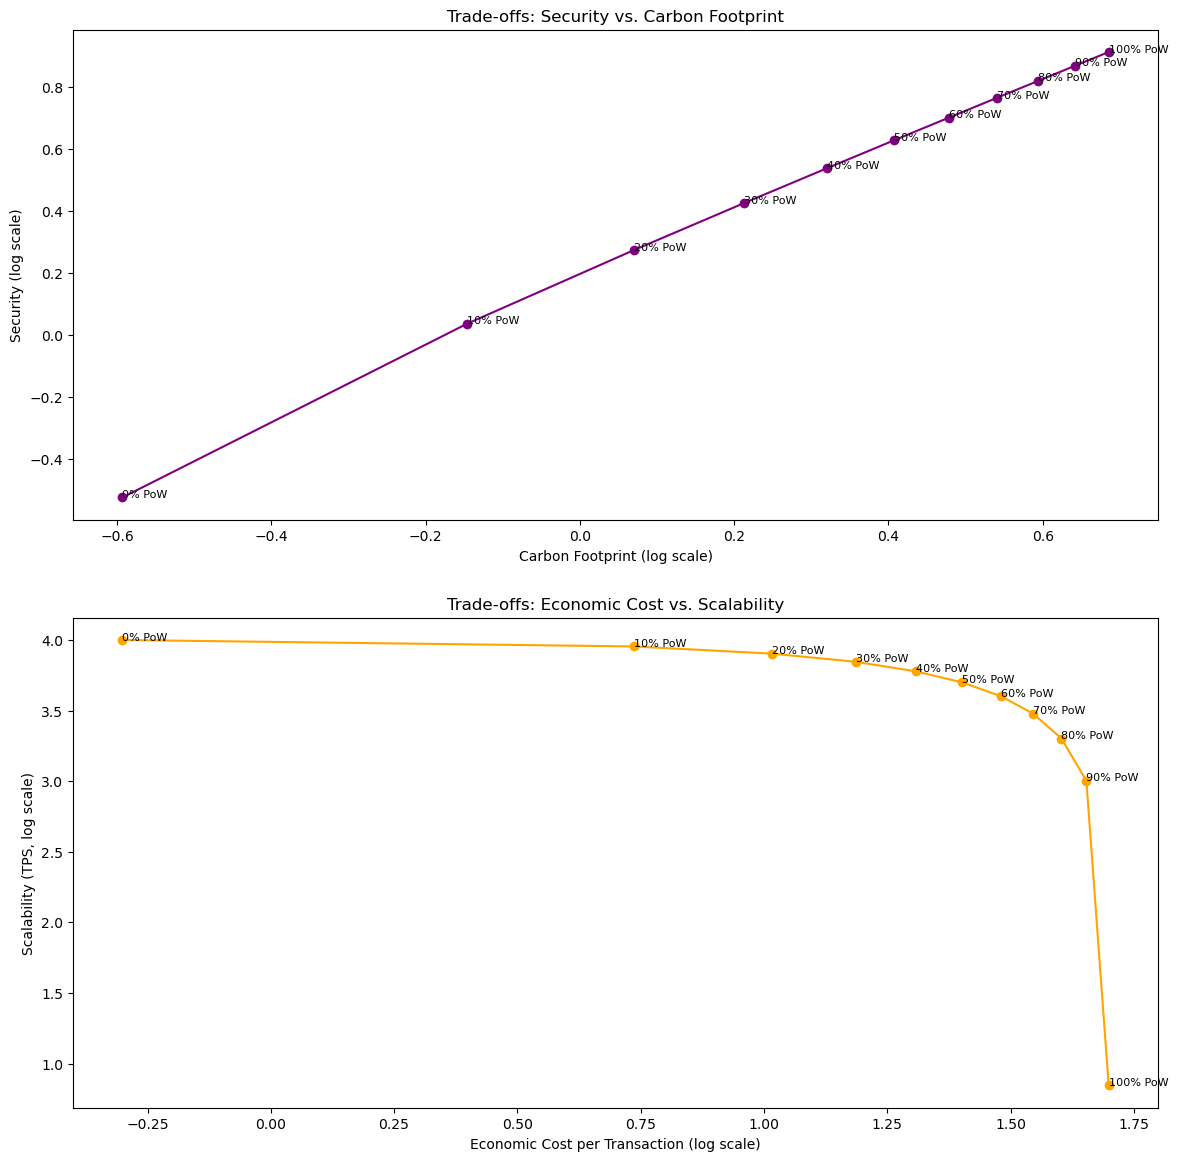

In [ ]:
# Create trade-off scatter plots
fig, axs = plt.subplots(2, 1, figsize=(14, 14))

# Security vs. Carbon Footprint
axs[0].plot(carbon_values_normalized, security_values_normalized, marker='o', linestyle='-', color='purple')
axs[0].set_xlabel("Carbon Footprint (log scale)")
axs[0].set_ylabel("Security (log scale)")
axs[0].set_title("Trade-offs: Security vs. Carbon Footprint")
for i, ratio in enumerate(ratios):
    axs[0].text(carbon_values_normalized[i], security_values_normalized[i], f"{int(ratio*100)}% PoW", fontsize=8)

# Economic Cost vs. Scalability
axs[1].plot(economic_costs_normalized, scalability_values_normalized, marker='o', linestyle='-', color='orange')
axs[1].set_xlabel("Economic Cost per Transaction (log scale)")
axs[1].set_ylabel("Scalability (TPS, log scale)")
axs[1].set_title("Trade-offs: Economic Cost vs. Scalability")
for i, ratio in enumerate(ratios):
    axs[1].text(economic_costs_normalized[i], scalability_values_normalized[i], f"{int(ratio*100)}% PoW", fontsize=8)

plt.show()

Graph 1: the more PoW, the higher the security and carbon footprint. as pow is reduced and pos is introduced, carbon emissions drops a lot while security decreases slightly. Note: a small PoW component (eg 20-50%) would keep strong security while reducing emissions. 

Graph 2: systems with mostly pow are costly and pos heavy systems are cheap and fast. Cost is coming from pow mining costs (electricity usage, mining hardware), pos staking cost (no more mining hardware so mostly transaction validation fee)

Economic cost = (PoW % * PoW cost) + (PoS % * PoS cost)
